# L0 · Fundamentos de Estatística para Executivos

**Análise Prescritiva — Camada de Alfabetização de Dados (Learning)**

| Campo | Detalhe |
|---|---|
| **Notebook** | L0 · Statistics Fundamentals for Executives |
| **Autor** | Matheus Mendes |
| **Data** | 27/julho/2026 |
| **Versão** | 1.0 |
| **Público-alvo** | Executivos não-técnicos que querem *entender* — não calcular |
| **Dependências** | numpy, pandas, plotly, matplotlib, seaborn |

---

## Por que este notebook existe

Numa reunião, a diferença entre soar como quem **entende os números** e quem
apenas **repete o slide** costuma ser uma única palavra: *média*, *volatilidade*,
*percentil*, *correlação*. Cada uma dessas palavras esconde uma decisão de milhões.

Este material foi desenhado no formato **narrativa-primeiro**:

> **Conceito → Intuição → Matemática → Código → Recado Executivo**

Você não precisa rodar uma linha de código para se beneficiar. Mas se rodar,
verá os cinco conceitos aplicados aos **dados reais do case BYD Camaçari**
(câmbio PTAX, custo da BOM importada, cenários de Monte Carlo).

**Objetivo final:** ao sair daqui, você deve conseguir dizer, com confiança e
sem blefe, *"Eu entendo o que esse dado está dizendo"*.

---

### Os 5 conceitos

| # | Conceito | A pergunta executiva que ele responde |
|---|----------|----------------------------------------|
| 1 | **Média, Mediana, Moda** | "Qual é o valor *típico*? E a média está me enganando?" |
| 2 | **Desvio-padrão (volatilidade)** | "Qual é o *risco* por trás dessa média?" |
| 3 | **Percentis** | "E se der errado? Qual é o meu pior 5%?" |
| 4 | **Correlação** | "O que se move *junto*? O que posso antecipar?" |
| 5 | **Visualização honesta** | "Esse gráfico está me contando a verdade?" |

---

In [1]:
# ──────────────────────────────────────────────────────────────
# Setup — tema escuro (#0d1117), paleta e dados reais do case BYD
# ──────────────────────────────────────────────────────────────
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = "notebook_connected"   # gráficos interativos embutidos
np.random.seed(42)

# ── Paleta (mesma linguagem visual do NB-01) ──────────────────
BG      = "#0d1117"   # fundo
INK     = "#e8edf5"   # texto principal
MUTED   = "#9baabb"   # texto secundário / eixos
GRID    = "#30363d"   # linhas de grade
CYAN    = "#22d3ee"   # destaque primário
TEAL    = "#14b8a6"   # positivo / estável
YELLOW  = "#eab308"   # atenção
RED     = "#ef4444"   # risco / negativo
VIOLET  = "#a78bfa"   # secundário

def style(fig, title, height=460):
    # Aplica o tema escuro padrao do case a qualquer figura Plotly
    fig.update_layout(
        template="plotly_dark", paper_bgcolor=BG, plot_bgcolor=BG,
        title=dict(text=title, x=0.5, font=dict(size=17, color=INK)),
        font=dict(color=INK, size=13),
        legend=dict(font=dict(color=MUTED), bgcolor="rgba(13,17,23,0.6)"),
        margin=dict(l=60, r=40, t=70, b=55), height=height,
    )
    fig.update_xaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    fig.update_yaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    return fig

# ── Dados reais do case (fonte: outputs/nb01_results.json) ────
BYD = {
    "ptax_atual":      5.1176,   # BRL/USD (PTAX, série BCB 1)
    "vol_hist_ann":    14.2,     # volatilidade histórica anualizada (%)
    "vol_calma_ann":    7.1,     # regime de calma
    "vol_turb_ann":    25.5,     # regime de turbulência (3.6x a calma)
    "imported_share":   0.42,    # 42% da BOM (bill of materials) é importada
    # Monte Carlo: 10.000 cenários de câmbio a 6 meses (NB-01)
    "mc_mean":          1.92,    # variação média do câmbio (%)
    "mc_std":          24.31,    # dispersão dos cenários (%)
    "mc_p5":          -27.82,    # pior 5% (real apreciando/depreciando)
    "mc_p50":          -0.31,    # cenário mediano
    "mc_p95":          37.21,    # melhor 5%
    "bom_p5":         -11.68,    # impacto no custo da BOM no pior 5% (pp)
    "bom_p95":         15.63,    # impacto no melhor 5% (pp)
}
print("Setup OK · tema escuro carregado · dados BYD:",
      f"PTAX={BYD['ptax_atual']} · vol={BYD['vol_hist_ann']}% a.a.")

Setup OK · tema escuro carregado · dados BYD: PTAX=5.1176 · vol=14.2% a.a.


---

## 1 · Média, Mediana e Moda — o "valor típico"

### ① Por que isto importa
A palavra **"média"** é a mais perigosa de qualquer reunião. Ela parece
inofensiva, mas um único número extremo — um fornecedor que atrasou 60 dias,
um mês de câmbio absurdo — pode inflar a média e esconder a realidade da
operação. Confiar na média errada já custou orçamento a muita gente.

### ② Conceito, sem jargão
São **três formas de responder à mesma pergunta**: *"qual é o valor típico?"*

- **Média** — some tudo e divida pela quantidade. O "centro de gravidade".
- **Mediana** — enfileire os valores do menor ao maior e pegue o do **meio**.
  Metade fica abaixo, metade acima. *Imune a extremos.*
- **Moda** — o valor que **mais se repete**. Útil para categorias.

### ③ Intuição — um exemplo de negócio
Cinco fornecedores prometeram entregar em ~2 semanas. Quatro cumpriram
(12–15 dias). Um travou e levou **60 dias**.

- A **média** vira ~22 dias → sugere que "em média atrasamos bastante".
- A **mediana** continua ~14 dias → mostra a **experiência típica** real.

O fornecedor problemático é um caso a resolver — não a régua do processo.
**Média para somar dinheiro; mediana para descrever a experiência típica.**

### ④ A matemática (acessível)
$$\text{Média } \bar{x} = \frac{x_1 + x_2 + \dots + x_n}{n}
\qquad
\text{Mediana} = \text{valor central da lista ordenada}$$

A média usa *todos* os valores (por isso sofre com extremos); a mediana usa
apenas a *posição* central (por isso os ignora).

In [2]:
# ── Prazos de entrega prometidos ~2 semanas; um fornecedor travou ──
prazos = np.array([12, 14, 13, 15, 60])          # dias
media   = prazos.mean()
mediana = np.median(prazos)
moda    = pd.Series(prazos).mode().iloc[0]

print(f"Média   = {media:.1f} dias   (puxada pelo outlier de 60)")
print(f"Mediana = {mediana:.1f} dias   (experiência típica real)")
print(f"Moda    = {moda:.0f} dias")

fig = go.Figure()
fig.add_bar(x=[f"Fornecedor {i+1}" for i in range(len(prazos))], y=prazos,
            marker_color=[TEAL, TEAL, TEAL, TEAL, RED],
            text=[f"{p}d" for p in prazos], textposition="outside",
            hovertemplate="%{x}: %{y} dias<extra></extra>", name="Prazo")
fig.add_hline(y=media, line=dict(color=YELLOW, width=2, dash="dash"),
              annotation_text=f"MÉDIA {media:.1f}d — enganosa",
              annotation_position="top left",
              annotation_font=dict(color=YELLOW))
fig.add_hline(y=mediana, line=dict(color=CYAN, width=2, dash="dot"),
              annotation_text=f"MEDIANA {mediana:.0f}d — realista",
              annotation_position="bottom left",
              annotation_font=dict(color=CYAN))
style(fig, "Um único outlier separa a MÉDIA da MEDIANA")
fig.update_yaxes(title="Prazo de entrega (dias)")
fig.show()

Média   = 22.8 dias   (puxada pelo outlier de 60)
Mediana = 14.0 dias   (experiência típica real)
Moda    = 12 dias


### ⑤ Recado executivo — Média, Mediana, Moda
> - **A média mente quando há extremos.** Se alguém citar só a média, pergunte:
>   *"E a mediana? Tem algum valor extremo puxando isso?"*
> - **Média para dinheiro** (custo total, receita — cada real conta);
>   **mediana para experiência típica** (prazos, tempos, salários).
> - **Moda para categorias**: "qual defeito mais aparece?", "qual canal mais converte?".

---

## 2 · Desvio-padrão — a volatilidade que a média esconde

### ① Por que isto importa
Duas operações podem ter **exatamente a mesma média** e riscos **opostos**.
A média diz *onde* o negócio está; o **desvio-padrão** diz *quão instável* ele
é. Ignorar isso é planejar o orçamento com o cenário médio e ser surpreendido
pelo cenário real.

### ② Conceito, sem jargão
Desvio-padrão = **o quanto os números balançam ao redor da média**.

- Desvio-padrão **baixo** → resultados previsíveis, agrupados. *Tranquilidade.*
- Desvio-padrão **alto** → resultados espalhados, imprevisíveis. *Risco.*

No mundo financeiro, essa mesma medida ganha o nome de **volatilidade**.

### ③ Intuição — câmbio calmo vs. turbulento (dados BYD)
No case BYD, a volatilidade do câmbio **não é constante**: alterna entre
regimes. Em **calma** o câmbio oscila ~7,1% ao ano; em **turbulência**,
~25,5% — **3,6× mais**. A média de longo prazo pode ser a mesma, mas planejar
compra de peças importadas no regime errado destrói a margem.

### ④ A matemática (acessível)
$$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

Em português: para cada ponto, meça a distância até a média, eleve ao quadrado
(para não cancelar positivos com negativos), tire a média disso e a raiz. O
resultado volta à unidade original — por isso é fácil de comunicar.

In [3]:
# ── Dois regimes de câmbio: mesma média, dispersões diferentes ──
n = 2000
media_ret = 0.0
calmo      = np.random.normal(media_ret, BYD["vol_calma_ann"], n)
turbulento = np.random.normal(media_ret, BYD["vol_turb_ann"],  n)

print(f"Regime CALMA       · média={calmo.mean():+.2f}%  · desvio={calmo.std():.1f}%")
print(f"Regime TURBULÊNCIA · média={turbulento.mean():+.2f}%  · desvio={turbulento.std():.1f}%")
print(f"-> Mesma média, risco {turbulento.std()/calmo.std():.1f}× maior.")

fig = go.Figure()
fig.add_histogram(x=calmo, name=f"Calma (σ≈{BYD['vol_calma_ann']}%)",
                  marker_color=TEAL, opacity=0.75, nbinsx=60,
                  hovertemplate="ret %{x:.1f}%<extra>Calma</extra>")
fig.add_histogram(x=turbulento, name=f"Turbulência (σ≈{BYD['vol_turb_ann']}%)",
                  marker_color=RED, opacity=0.6, nbinsx=60,
                  hovertemplate="ret %{x:.1f}%<extra>Turbulência</extra>")
fig.add_vline(x=media_ret, line=dict(color=INK, width=2, dash="dash"),
              annotation_text="mesma média", annotation_font=dict(color=INK))
fig.update_layout(barmode="overlay")
style(fig, "Mesma média, riscos opostos — o desvio-padrão revela a diferença")
fig.update_xaxes(title="Retorno diário do câmbio (%)")
fig.update_yaxes(title="Frequência (nº de dias)")
fig.show()

Regime CALMA       · média=+0.32%  · desvio=7.0%
Regime TURBULÊNCIA · média=-0.16%  · desvio=25.6%
-> Mesma média, risco 3.7× maior.


### ⑤ Recado executivo — Desvio-padrão / Volatilidade
> - **Nunca aceite uma média sozinha.** Sempre pergunte: *"E a variação? Qual o
>   melhor e o pior caso ao redor disso?"*
> - **Volatilidade é dinheiro:** um insumo com preço volátil exige hedge,
>   estoque ou contrato — mesmo que o preço médio pareça bom.
> - **Regras práticas** (distribuições típicas): ~**2 em cada 3** resultados caem
>   dentro de ±1 desvio da média; ~**19 em cada 20** dentro de ±2 desvios.
>   Fora disso é sinal de estresse.

---

## 3 · Percentis — "e se der errado?"

### ① Por que isto importa
"Em média vai dar certo" é uma frase que já quebrou empresas. O que mantém uma
operação viva não é o cenário médio — é saber, **antes**, qual é o **pior 5%**
e se a empresa sobrevive a ele. Percentis são a linguagem do risco de cauda.

### ② Conceito, sem jargão
Um **percentil** diz **onde você está na fila**. O **percentil 5 (P5)** é o
valor abaixo do qual caem apenas os 5% piores cenários. O **P50** é a mediana
(o meio). O **P95**, os 5% melhores.

Executivos vivem de três números: **P5 (pior caso plausível), P50 (típico),
P95 (melhor caso plausível)**.

### ③ Intuição — Monte Carlo do câmbio BYD
No NB-01 simulamos **10.000 cenários** de câmbio a 6 meses. O cenário mediano é
quase neutro (**P50 ≈ 0%**), mas a cauda é dura: no **P5**, o câmbio move
**−27,8%**, o que joga o custo da BOM importada em **−11,7 pontos percentuais**.
É esse P5 — não a média — que define quanto hedge contratar.

### ④ A matemática (acessível)
$$P_k = \text{valor tal que } k\% \text{ das observações ficam abaixo dele}$$

Não há fórmula assustadora: ordene os dados e conte a posição. O P50 é a
mediana; o P25 e o P75 marcam o "miolo" onde vive metade dos casos.

In [4]:
# ── Reconstrução do Monte Carlo (10k cenários, cauda gorda t-Student) ──
sim = np.random.standard_t(5, 10_000)
sim = sim / sim.std() * BYD["mc_std"] + BYD["mc_mean"]   # calibra média/desvio

p5, p50, p95 = np.percentile(sim, [5, 50, 95])
print(f"P5  (pior 5%)     = {p5:+.1f}%   -> dispare o plano de hedge aqui")
print(f"P50 (mediano)     = {p50:+.1f}%")
print(f"P95 (melhor 5%)   = {p95:+.1f}%")
print(f"Prob. de perda (<0) = {(sim<0).mean()*100:.0f}%")

fig = go.Figure()
fig.add_histogram(x=sim, nbinsx=80, marker_color=CYAN, opacity=0.75,
                  hovertemplate="variação %{x:.1f}%<extra></extra>", name="cenários")
for val, cor, txt in [(p5, RED, f"P5  {p5:+.0f}%"),
                      (p50, INK, f"P50 {p50:+.0f}%"),
                      (p95, TEAL, f"P95 {p95:+.0f}%")]:
    fig.add_vline(x=val, line=dict(color=cor, width=2, dash="dash"),
                  annotation_text=txt, annotation_font=dict(color=cor))
style(fig, "10.000 cenários de câmbio — a média esconde a cauda (P5)")
fig.update_xaxes(title="Variação do câmbio em 6 meses (%)")
fig.update_yaxes(title="Nº de cenários")
fig.show()

P5  (pior 5%)     = -36.0%   -> dispare o plano de hedge aqui
P50 (mediano)     = +1.6%
P95 (melhor 5%)   = +40.1%
Prob. de perda (<0) = 47%


### ⑤ Recado executivo — Percentis
> - **Planeje pelo P5, não pela média.** A pergunta que salva o caixa é
>   *"qual é o meu pior caso plausível e eu sobrevivo a ele?"*.
> - **P50 é a verdade típica** — mais honesto que a média quando há caudas.
> - **Fale em trilhas, não em ponto único:** "esperamos ~X (P50), entre Y (P5)
>   e Z (P95)". Isso demonstra domínio do risco em qualquer comitê.

---

## 4 · Correlação — o que se move junto

### ① Por que isto importa
Antecipar é vantagem competitiva. Se você sabe que **A** costuma subir quando
**B** sobe, um movimento em B vira um **aviso antecipado** sobre A. Correlação é
o instrumento que transforma "reagir" em "prever".

### ② Conceito, sem jargão
A correlação é **um número entre −1 e +1** que mede se duas coisas se movem
juntas:

- **+1** → sobem e descem em perfeita sintonia.
- **0** → não têm relação aparente.
- **−1** → quando uma sobe, a outra desce (perfeitamente).

⚠️ **Correlação não é causa.** Duas coisas podem andar juntas por coincidência
ou por causa de uma terceira. Correlação abre a investigação — não a encerra.

### ③ Intuição — câmbio × custo da BOM (dados BYD)
42% da lista de materiais da BYD é importada. Quando o dólar sobe, o custo
dessa parcela sobe **quase na mesma direção** — uma correlação forte e
**positiva**. Não é coincidência: é mecânica de custo. Por isso o câmbio é o
fator #1 de vulnerabilidade da operação.

### ④ A matemática (acessível)
$$r = \frac{\text{covariância}(x, y)}{\sigma_x \, \sigma_y}$$

Traduzindo: mede-se o quanto x e y "desviam juntos" da própria média
(covariância) e divide-se pelas volatilidades individuais para chegar a uma
escala universal de −1 a +1 — comparável entre quaisquer pares.

In [5]:
# ── Três intuições de correlação + o caso real câmbio × BOM ──
n = 300
base = np.random.normal(0, 1, n)

def par(r):
    ruido = np.random.normal(0, 1, n)
    y = r * base + np.sqrt(max(1 - r**2, 0)) * ruido
    return y

fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.07,
    subplot_titles=("r ≈ +0,9 · sobem juntos",
                    "r ≈ 0 · sem relação",
                    "r ≈ −0,9 · espelho"))
for col, (r_alvo, cor) in enumerate([(0.9, TEAL), (0.0, MUTED), (-0.9, RED)], start=1):
    y = par(r_alvo)
    r_real = np.corrcoef(base, y)[0, 1]
    fig.add_scatter(x=base, y=y, mode="markers", row=1, col=col,
                    marker=dict(color=cor, size=5, opacity=0.6),
                    name=f"r={r_real:+.2f}",
                    hovertemplate="x=%{x:.2f}, y=%{y:.2f}<extra></extra>")
style(fig, "Intuição visual: o que cada correlação parece", height=420)
fig.update_xaxes(color=MUTED, gridcolor=GRID); fig.update_yaxes(color=MUTED, gridcolor=GRID)
fig.update_layout(showlegend=False)
fig.show()

# ── Caso real: câmbio (%) × impacto no custo da BOM (pp) ──
cambio = np.random.normal(BYD["mc_mean"], BYD["mc_std"], 800)
bom = cambio * BYD["imported_share"] + np.random.normal(0, 1.2, 800)   # 42% + ruído
r_bom = np.corrcoef(cambio, bom)[0, 1]
print(f"Correlação câmbio × custo da BOM = {r_bom:+.2f}  (forte e positiva)")

fig2 = go.Figure()
fig2.add_scatter(x=cambio, y=bom, mode="markers",
                 marker=dict(color=CYAN, size=5, opacity=0.5),
                 hovertemplate="câmbio %{x:.1f}% -> BOM %{y:.1f}pp<extra></extra>",
                 name="cenários")
coef = np.polyfit(cambio, bom, 1)
xs = np.array([cambio.min(), cambio.max()])
fig2.add_scatter(x=xs, y=np.polyval(coef, xs), mode="lines",
                 line=dict(color=YELLOW, width=3), name="tendência")
style(fig2, f"Câmbio × custo da BOM importada · r = {r_bom:+.2f}")
fig2.update_xaxes(title="Variação do câmbio (%)")
fig2.update_yaxes(title="Impacto no custo da BOM (pontos %)")
fig2.show()

Correlação câmbio × custo da BOM = +0.99  (forte e positiva)


### ⑤ Recado executivo — Correlação
> - **Correlação forte = alerta antecipado.** Monitore o fator "líder" (câmbio) e
>   você vê o custo chegar antes de bater no balanço.
> - **+1 e −1 são raros; o interessante mora no meio.** Um r de ±0,5 já é
>   material para decisão.
> - **Nunca confunda com causa.** Pergunte sempre: *"há um mecanismo real, ou
>   isso é coincidência / um terceiro fator?"* Antes de agir, exija o "porquê".

---

## 5 · Visualização honesta — gráficos que contam a verdade

### ① Por que isto importa
O mesmo dado, exato e verdadeiro, pode contar **duas histórias opostas** apenas
mudando o eixo. Executivos tomam decisões olhando gráficos em segundos — e o
truque mais comum (nem sempre mal-intencionado) é o **eixo Y truncado**, que
transforma uma diferença trivial em um "abismo" dramático.

### ② Conceito, sem jargão
Três princípios separam um gráfico honesto de um enganoso:

1. **Barras começam no zero.** O comprimento da barra *é* o valor. Cortar a base
   distorce a comparação.
2. **A escala tem que ser coerente** com a magnitude da diferença real.
3. **O gráfico certo para a pergunta certa:** barra compara categorias, linha
   mostra evolução no tempo, dispersão mostra relação.

### ③ Intuição — a mesma variação de market share
Suponha que o share do concorrente foi de **20,0% para 20,8%** — um avanço de
0,8 ponto. Com o eixo começando em 19,5%, isso vira uma "torre" alarmante. Com
o eixo no zero, vira o que é: um passo modesto. **Mesmo dado, duas reuniões
diferentes.**

### ④ O princípio (a "matemática" aqui é de percepção)
O olho lê **proporção de área/comprimento**, não o rótulo do eixo. Se a base não
é zero, a razão visual entre as barras deixa de bater com a razão real dos
números — e a intuição do público é sequestrada.

In [6]:
# ── Mesmo dado, dois eixos: o truque do eixo truncado ──
cat = ["Nós", "Concorrente"]
share = [20.0, 20.8]        # market share (%) — diferença real de 0,8pp

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.15,
    subplot_titles=("❌ ENGANOSO · eixo começa em 19,5%",
                    "✅ HONESTO · eixo começa em zero"))

fig.add_bar(x=cat, y=share, row=1, col=1, marker_color=[CYAN, RED],
            text=[f"{s}%" for s in share], textposition="outside",
            hovertemplate="%{x}: %{y}%<extra></extra>")
fig.add_bar(x=cat, y=share, row=1, col=2, marker_color=[CYAN, RED],
            text=[f"{s}%" for s in share], textposition="outside",
            hovertemplate="%{x}: %{y}%<extra></extra>")

fig.update_yaxes(range=[19.5, 21.0], row=1, col=1, color=MUTED, gridcolor=GRID,
                 title="share (%)")
fig.update_yaxes(range=[0, 25],      row=1, col=2, color=MUTED, gridcolor=GRID,
                 title="share (%)")
fig.update_xaxes(color=MUTED, gridcolor=GRID)
style(fig, "Diferença real: 0,8 ponto — só o eixo muda a história", height=460)
fig.update_layout(showlegend=False)
fig.show()

print("Diferença real de share: 0,8 pp.")
print("À esquerda parece uma ameaça existencial; à direita, um ajuste modesto.")

Diferença real de share: 0,8 pp.
À esquerda parece uma ameaça existencial; à direita, um ajuste modesto.


### ⑤ Recado executivo — Visualização honesta
> - **Olhe o eixo Y primeiro.** Barras que não começam no zero são o truque #1
>   para dramatizar diferenças pequenas.
> - **Peça o número absoluto por trás da forma.** "Isso é quantos pontos, em
>   termos reais?" desarma qualquer gráfico enganoso.
> - **Combine forma e pergunta:** linha para tempo, barra para categorias,
>   dispersão para relação. Gráfico errado confunde mesmo com dado certo.

## 6 · Visualizações em PNG — lendo BYD/PTAX com o olhar

As três figuras abaixo usam exemplos do case BYD Camaçari e o mesmo tema escuro do notebook. Cada gráfico também é exportado como PNG para `outputs/learning/`, permitindo reutilizar as imagens em apresentações sem perder a leitura executiva.

### 6.1 · Distribuição da PTAX — média, mediana e moda

A distribuição mostra como a PTAX se espalha em uma amostra de observações ao redor do nível atual de R$ 5,12 por dólar. A média usa todos os pontos, a mediana marca o centro da fila e a moda identifica a faixa que aparece com mais frequência; comparar as três ajuda a perceber quando um extremo está puxando a conversa.

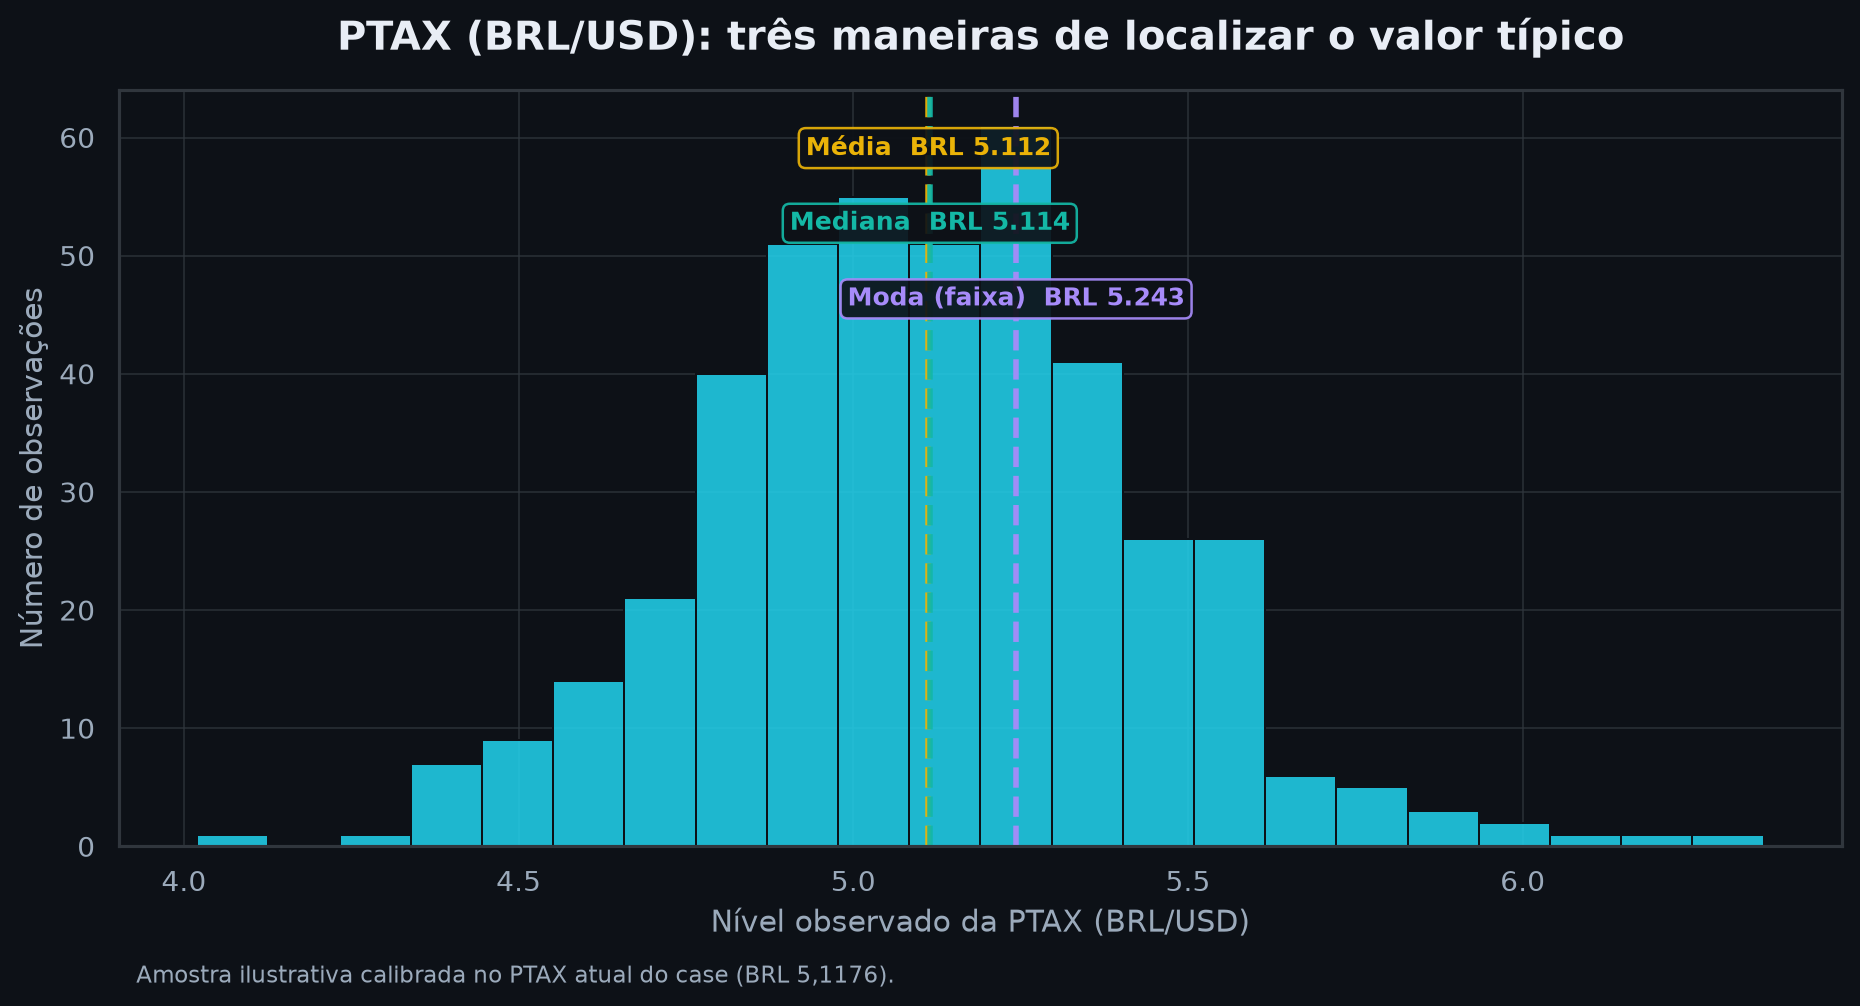

PNG salvo em: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l0_histogram-central-tendency.png
Média=5.112 · mediana=5.114 · moda (faixa)=5.243


In [7]:
# ── PNG 1 · Distribuição da PTAX com média, mediana e moda ──
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

L0_OUTPUT_DIR = Path(r"C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning")
L0_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Mantém a linguagem visual do case em figuras estáticas.
sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": INK,
    "axes.labelcolor": MUTED,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "DejaVu Sans",
})

def style_mpl_axes(ax):
    ax.set_facecolor(BG)
    ax.grid(True, color=GRID, linewidth=0.8, alpha=0.65)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.tick_params(colors=MUTED)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)

rng_l0_hist = np.random.default_rng(20260727)
ptax_levels = np.clip(
    rng_l0_hist.normal(BYD["ptax_atual"], 0.32, 420),
    3.8,
    6.6,
)
# Três observações estressadas tornam visível o efeito de extremos na média.
ptax_levels = np.concatenate([ptax_levels, [4.02, 6.18, 6.36]])
media_ptax = float(np.mean(ptax_levels))
mediana_ptax = float(np.median(ptax_levels))
hist_counts, hist_edges = np.histogram(ptax_levels, bins=22)
modal_bin = int(np.argmax(hist_counts))
moda_ptax = float((hist_edges[modal_bin] + hist_edges[modal_bin + 1]) / 2)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
style_mpl_axes(ax)
sns.histplot(
    ptax_levels,
    bins=22,
    color=CYAN,
    edgecolor=BG,
    linewidth=0.8,
    alpha=0.86,
    ax=ax,
)
for value, label, color, y_pos in [
    (media_ptax, f"Média  BRL {media_ptax:.3f}", YELLOW, 0.94),
    (mediana_ptax, f"Mediana  BRL {mediana_ptax:.3f}", TEAL, 0.84),
    (moda_ptax, f"Moda (faixa)  BRL {moda_ptax:.3f}", VIOLET, 0.74),
]:
    ax.axvline(value, color=color, linewidth=2.2, linestyle="--", alpha=0.95)
    ax.text(
        value,
        y_pos,
        label,
        transform=ax.get_xaxis_transform(),
        color=color,
        fontsize=10,
        fontweight="bold",
        ha="center",
        va="top",
        bbox=dict(boxstyle="round,pad=0.28", facecolor=BG, edgecolor=color, alpha=0.92),
    )

ax.set_title(
    "PTAX (BRL/USD): três maneiras de localizar o valor típico",
    color=INK,
    fontsize=16,
    fontweight="bold",
    pad=16,
)
ax.set_xlabel("Nível observado da PTAX (BRL/USD)")
ax.set_ylabel("Número de observações")
ax.text(
    0.01,
    -0.18,
    "Amostra ilustrativa calibrada no PTAX atual do case (BRL 5,1176).",
    transform=ax.transAxes,
    color=MUTED,
    fontsize=9,
)
fig.tight_layout()
hist_path = L0_OUTPUT_DIR / "l0_histogram-central-tendency.png"
fig.savefig(hist_path, dpi=180, facecolor=BG, bbox_inches="tight")
display(Image(filename=str(hist_path)))
plt.close(fig)
print(f"PNG salvo em: {hist_path}")
print(f"Média={media_ptax:.3f} · mediana={mediana_ptax:.3f} · moda (faixa)={moda_ptax:.3f}")

### 6.2 · Box plot — quartis e faixa típica

Este box plot resume cenários de variação da PTAX em seis meses, como os usados para avaliar a BOM importada da BYD. A caixa vai do primeiro quartil (P25) ao terceiro (P75), portanto contém metade dos cenários; a linha central é a mediana e os pontos afastados sinalizam situações fora do padrão.

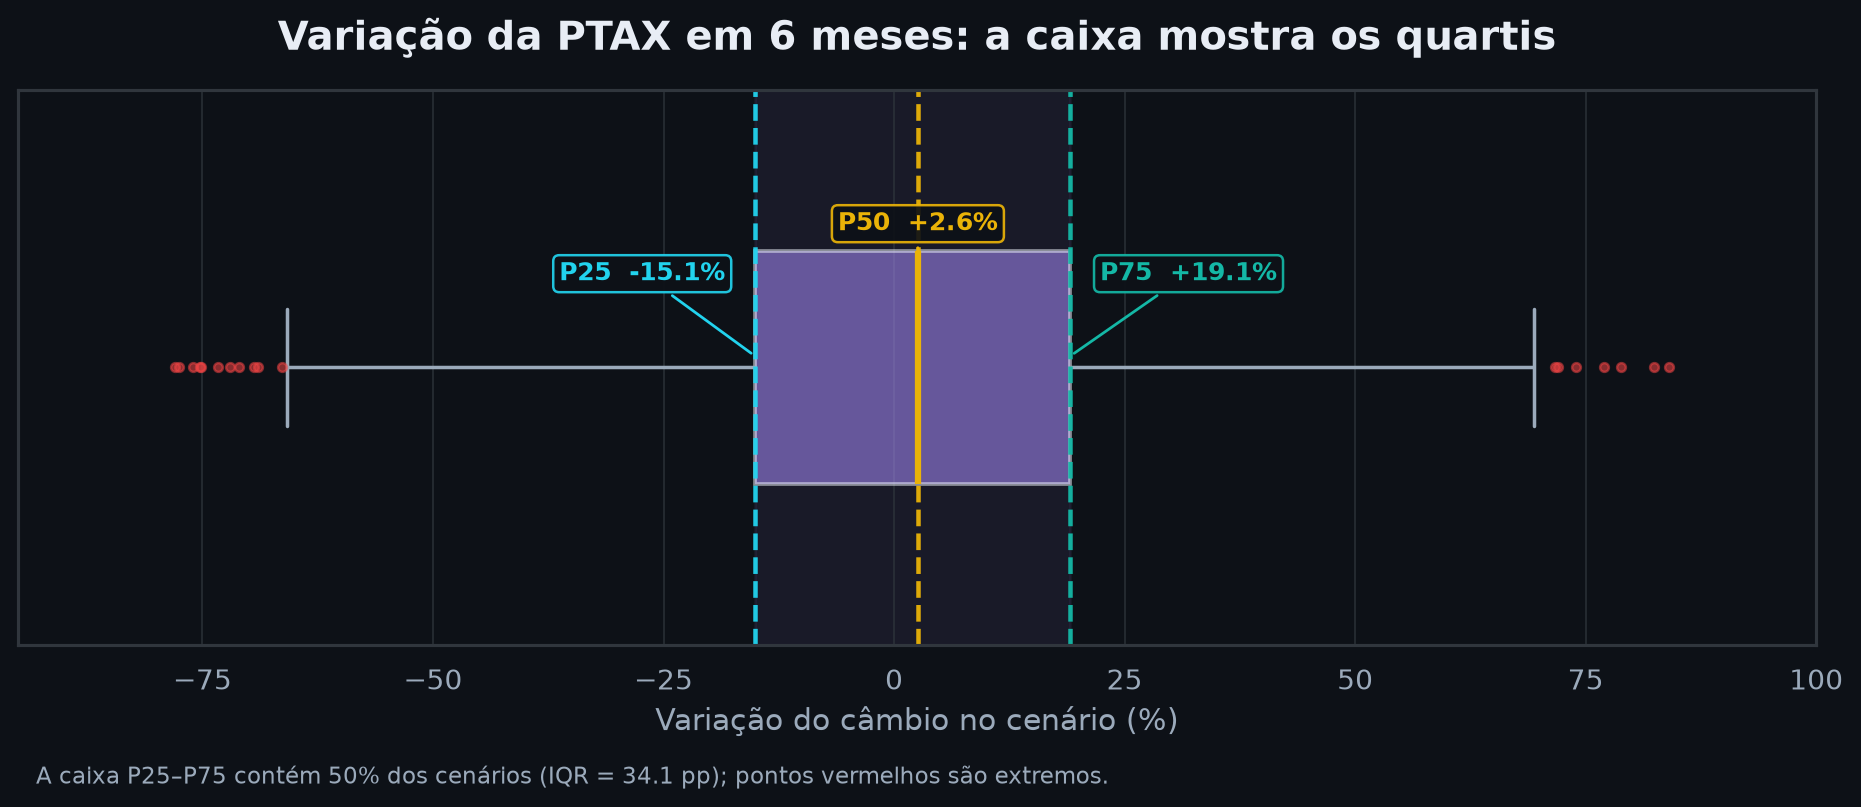

PNG salvo em: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l0_boxplot-quartiles.png
P25=-15.05% · P50=+2.59% · P75=+19.08%


In [8]:
# ── PNG 2 · Box plot com quartis da distribuição de PTAX ──
rng_l0_box = np.random.default_rng(20260728)
# Cenários compactos para manter quartis e extremos legíveis no mesmo quadro.
ptax_change_6m = rng_l0_box.normal(BYD["mc_mean"], BYD["mc_std"], 2_500)
ptax_change_6m = np.clip(ptax_change_6m, -82, 88)
ptax_change_6m = np.concatenate([ptax_change_6m, [-78.0, -69.0, 74.0, 84.0]])
q1_ptax, mediana_ptax_box, q3_ptax = np.percentile(ptax_change_6m, [25, 50, 75])
iqr_ptax = q3_ptax - q1_ptax

fig, ax = plt.subplots(figsize=(10.5, 4.8))
style_mpl_axes(ax)
sns.boxplot(
    x=ptax_change_6m,
    orient="h",
    width=0.42,
    color=VIOLET,
    linewidth=1.5,
    fliersize=3.5,
    flierprops=dict(
        marker="o",
        markerfacecolor=RED,
        markeredgecolor=RED,
        alpha=0.55,
        markersize=3.5,
    ),
    boxprops=dict(facecolor=VIOLET, alpha=0.55, edgecolor=INK),
    medianprops=dict(color=YELLOW, linewidth=2.5),
    whiskerprops=dict(color=MUTED, linewidth=1.4),
    capprops=dict(color=MUTED, linewidth=1.4),
    ax=ax,
)
ax.axvspan(q1_ptax, q3_ptax, color=VIOLET, alpha=0.08, zorder=0)
for value, label, color, offset, ha in [
    (q1_ptax, f"P25  {q1_ptax:+.1f}%", CYAN, (-12, 28), "right"),
    (mediana_ptax_box, f"P50  {mediana_ptax_box:+.1f}%", YELLOW, (0, 48), "center"),
    (q3_ptax, f"P75  {q3_ptax:+.1f}%", TEAL, (12, 28), "left"),
]:
    ax.axvline(value, color=color, linewidth=1.8, linestyle="--", alpha=0.95)
    ax.annotate(
        label,
        xy=(value, 0.52),
        xycoords=("data", "axes fraction"),
        xytext=offset,
        textcoords="offset points",
        color=color,
        fontsize=10,
        fontweight="bold",
        ha=ha,
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.24", facecolor=BG, edgecolor=color, alpha=0.92),
        arrowprops=dict(arrowstyle="-", color=color, linewidth=1.1),
    )

ax.set_title(
    "Variação da PTAX em 6 meses: a caixa mostra os quartis",
    color=INK,
    fontsize=16,
    fontweight="bold",
    pad=16,
)
ax.set_xlabel("Variação do câmbio no cenário (%)")
ax.set_ylabel("")
ax.set_yticks([])
ax.set_xlim(-95, 100)
ax.text(
    0.01,
    -0.25,
    f"A caixa P25–P75 contém 50% dos cenários (IQR = {iqr_ptax:.1f} pp); pontos vermelhos são extremos.",
    transform=ax.transAxes,
    color=MUTED,
    fontsize=9,
)
fig.tight_layout()
box_path = L0_OUTPUT_DIR / "l0_boxplot-quartiles.png"
fig.savefig(box_path, dpi=180, facecolor=BG, bbox_inches="tight")
display(Image(filename=str(box_path)))
plt.close(fig)
print(f"PNG salvo em: {box_path}")
print(f"P25={q1_ptax:+.2f}% · P50={mediana_ptax_box:+.2f}% · P75={q3_ptax:+.2f}%")

### 6.3 · Dispersão — câmbio e custo da BOM importada

Cada ponto representa um cenário de variação do câmbio e o impacto correspondente na parcela importada da BOM da BYD (42%). A linha de tendência resume a direção do relacionamento: quando a PTAX sobe, o custo em reais tende a subir junto; o coeficiente `r` ajuda a medir quão consistente é esse movimento, sem confundir associação com causalidade.

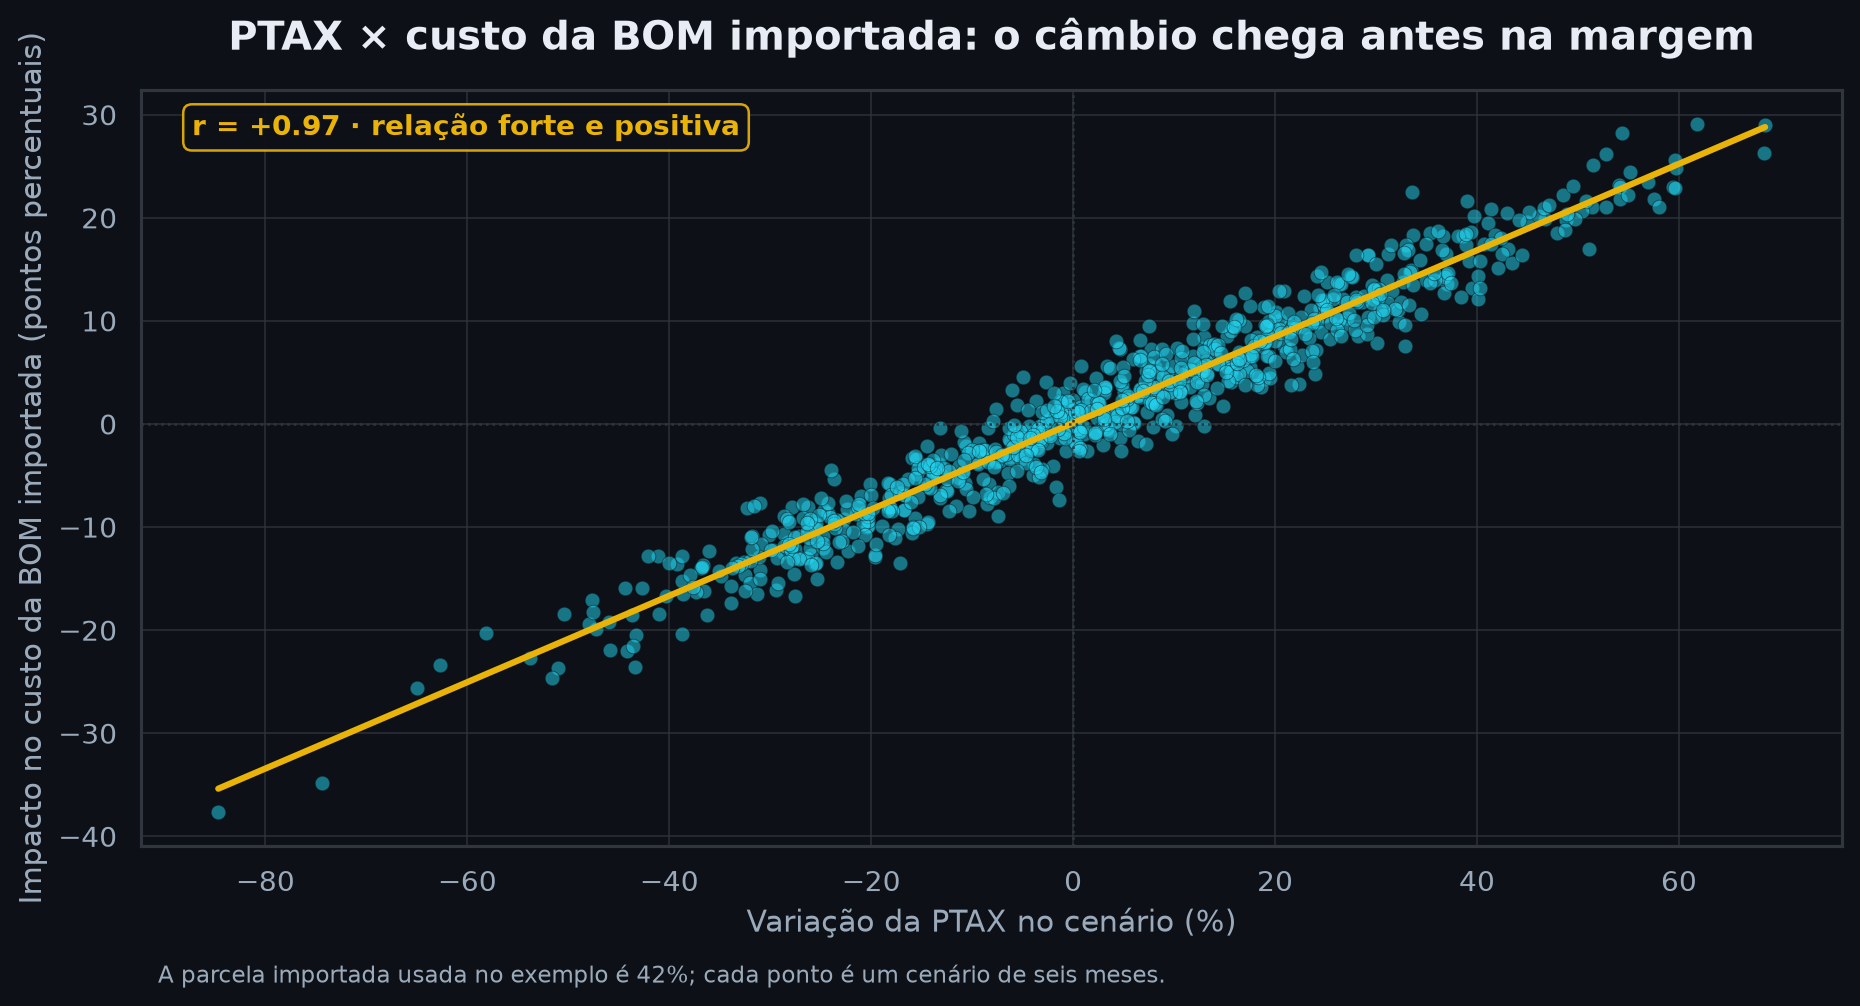

PNG salvo em: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l0_scatter-correlation.png
Correlação PTAX × BOM importada = +0.975


In [9]:
# ── PNG 3 · Dispersão PTAX × impacto da BOM com linha de correlação ──
rng_l0_scatter = np.random.default_rng(20260729)
cambio_pct_l0 = rng_l0_scatter.normal(BYD["mc_mean"], BYD["mc_std"], 800)
bom_impact_pp_l0 = (
    cambio_pct_l0 * BYD["imported_share"]
    + rng_l0_scatter.normal(0, 2.4, cambio_pct_l0.size)
)
r_l0 = float(np.corrcoef(cambio_pct_l0, bom_impact_pp_l0)[0, 1])

fig, ax = plt.subplots(figsize=(10.5, 5.8))
style_mpl_axes(ax)
sns.regplot(
    x=cambio_pct_l0,
    y=bom_impact_pp_l0,
    ax=ax,
    ci=None,
    scatter_kws=dict(s=34, color=CYAN, alpha=0.52, edgecolor=BG, linewidths=0.35),
    line_kws=dict(color=YELLOW, linewidth=2.5),
)
ax.axhline(0, color=GRID, linewidth=1.0, linestyle=":")
ax.axvline(0, color=GRID, linewidth=1.0, linestyle=":")
ax.text(
    0.03,
    0.94,
    f"r = {r_l0:+.2f} · relação forte e positiva",
    transform=ax.transAxes,
    color=YELLOW,
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.32", facecolor=BG, edgecolor=YELLOW, alpha=0.92),
)
ax.set_title(
    "PTAX × custo da BOM importada: o câmbio chega antes na margem",
    color=INK,
    fontsize=16,
    fontweight="bold",
    pad=16,
)
ax.set_xlabel("Variação da PTAX no cenário (%)")
ax.set_ylabel("Impacto no custo da BOM importada (pontos percentuais)")
ax.text(
    0.01,
    -0.18,
    f"A parcela importada usada no exemplo é {BYD['imported_share']:.0%}; cada ponto é um cenário de seis meses.",
    transform=ax.transAxes,
    color=MUTED,
    fontsize=9,
)
fig.tight_layout()
scatter_path = L0_OUTPUT_DIR / "l0_scatter-correlation.png"
fig.savefig(scatter_path, dpi=180, facecolor=BG, bbox_inches="tight")
display(Image(filename=str(scatter_path)))
plt.close(fig)
print(f"PNG salvo em: {scatter_path}")
print(f"Correlação PTAX × BOM importada = {r_l0:+.3f}")

**Leitura executiva das três imagens:** a média é apenas um ponto de partida; a faixa e os extremos mostram o risco que precisa caber no plano. No caso BYD, a relação entre PTAX e BOM traduz uma exposição operacional concreta — acompanhar o câmbio é uma forma de antecipar pressão de margem.

---

## Resumo Executivo — o que levar para a reunião

Cinco frases que, ditas com contexto, mostram domínio dos dados:

1. *"A média está sendo puxada por um extremo? Me mostra a **mediana**."*
2. *"Qual é a **volatilidade** por trás dessa média — o melhor e o pior caso?"*
3. *"Não quero só o cenário médio; quero o **P5**. Sobrevivemos a ele?"*
4. *"O que se **correlaciona** com isso? Tem mecanismo real ou é coincidência?"*
5. *"Esse **eixo** começa no zero? Qual é a diferença em números absolutos?"*

O bloco abaixo consolida os números do case e exporta um resumo executivo
para `outputs/learning/l0_stats_executive.json`.

In [10]:
# ──────────────────────────────────────────────────────────────
# Exporta o resumo executivo em JSON
# ──────────────────────────────────────────────────────────────
NOTEBOOK_ROOT = Path(r"C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva")
OUT_DIR = NOTEBOOK_ROOT / "outputs" / "learning"
OUT_DIR.mkdir(parents=True, exist_ok=True)

resumo = {
    "notebook": "L0 · Statistics Fundamentals for Executives",
    "computed_at": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "audience": "executivos nao-tecnicos",
    "format": "narrativa-primeiro (Conceito -> Intuicao -> Matematica -> Codigo -> Recado)",
    "concepts": {
        "central_tendency": {
            "titulo": "Media, Mediana, Moda",
            "exemplo": "prazos [12,14,13,15,60] dias",
            "media": round(float(np.mean([12,14,13,15,60])), 1),
            "mediana": float(np.median([12,14,13,15,60])),
            "insight": "a media mente com extremos; use mediana para experiencia tipica",
            "pergunta_reuniao": "E a mediana? Tem valor extremo puxando a media?",
        },
        "dispersion": {
            "titulo": "Desvio-padrao / Volatilidade",
            "vol_calma_ann_pct": BYD["vol_calma_ann"],
            "vol_turbulencia_ann_pct": BYD["vol_turb_ann"],
            "razao_risco": round(BYD["vol_turb_ann"]/BYD["vol_calma_ann"], 1),
            "insight": "mesma media pode esconder riscos opostos",
            "pergunta_reuniao": "Qual a variacao ao redor dessa media?",
        },
        "percentiles": {
            "titulo": "Percentis (P5 / P50 / P95)",
            "p5_cambio_pct": BYD["mc_p5"],
            "p50_cambio_pct": BYD["mc_p50"],
            "p95_cambio_pct": BYD["mc_p95"],
            "bom_p5_pp": BYD["bom_p5"],
            "bom_p95_pp": BYD["bom_p95"],
            "insight": "planeje pelo P5 (pior caso plausivel), nao pela media",
            "pergunta_reuniao": "Qual e o P5 e nos sobrevivemos a ele?",
        },
        "correlation": {
            "titulo": "Correlacao",
            "escala": "-1 a +1",
            "cambio_x_bom_imported_share": BYD["imported_share"],
            "insight": "correlacao forte = alerta antecipado; correlacao != causa",
            "pergunta_reuniao": "Ha mecanismo real ou e coincidencia?",
        },
        "visualization": {
            "titulo": "Visualizacao honesta",
            "exemplo": "share 20.0% -> 20.8% (0.8pp) com eixo truncado vs zero",
            "insight": "barras devem comecar no zero; o eixo pode sequestrar a intuicao",
            "pergunta_reuniao": "Esse eixo comeca no zero? Quanto e em numeros absolutos?",
        },
    },
    "byd_context": BYD,
    "executive_phrases": [
        "A media esta puxada por um extremo? Me mostra a mediana.",
        "Qual a volatilidade por tras dessa media - melhor e pior caso?",
        "Nao quero so o cenario medio; quero o P5. Sobrevivemos a ele?",
        "O que se correlaciona com isso? Tem mecanismo real ou coincidencia?",
        "Esse eixo comeca no zero? Qual a diferenca em numeros absolutos?",
    ],
}

out_path = OUT_DIR / "l0_stats_executive.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(resumo, f, indent=2, ensure_ascii=False)

print("Resumo executivo salvo em:")
print(" ", out_path)
print()
print("Frases para levar a reuniao:")
for i, frase in enumerate(resumo["executive_phrases"], 1):
    print(f"  {i}. {frase}")

Resumo executivo salvo em:
  C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l0_stats_executive.json

Frases para levar a reuniao:
  1. A media esta puxada por um extremo? Me mostra a mediana.
  2. Qual a volatilidade por tras dessa media - melhor e pior caso?
  3. Nao quero so o cenario medio; quero o P5. Sobrevivemos a ele?
  4. O que se correlaciona com isso? Tem mecanismo real ou coincidencia?
  5. Esse eixo comeca no zero? Qual a diferenca em numeros absolutos?


---

*L0 concluído.* Se você chegou até aqui, já consegue interrogar qualquer
slide de dados com cinco perguntas afiadas — e dizer, sem blefe,
**"eu entendo o que esse dado está dizendo"**.

**Próximo nível:** `NB-01` (câmbio e volatilidade com GARCH + Markov) aplica
exatamente estes conceitos em profundidade quantitativa.